# Resultados do treino - PCA/EOF + LSTM

Visualiza os artefatos gerados por `src/train_pca_lstm.py` (branch `mazeeqe`):
curvas de treino, comparacao com os baselines (persistencia e climatologia) e
mapas espaciais de exemplo em diferentes horizontes de previsao (lag).

Le os arquivos salvos em `experiments/pca_lstm_run1/` - nao reprocessa os dados
nem re-treina o modelo (para isso, rode `python3 -m src.train_pca_lstm` a
partir da raiz do repositorio).

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RUN_DIR = "experiments/pca_lstm_run1"

# Paleta fixa por serie (nunca ciclada) - modelo em destaque, baselines em tons neutros
COLORS = {
    "modelo": "#0072B2",       # azul - resultado principal
    "persistencia": "#999999", # cinza - baseline mais simples
    "climatologia": "#E69F00", # laranja - segundo baseline
}
LABELS = {"modelo": "PCA + LSTM", "persistencia": "Persistencia", "climatologia": "Climatologia"}

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Curvas de treino

MSE (no espaco reduzido do PCA) por epoca, treino vs validacao interna. A linha vertical marca a epoca escolhida por early stopping.

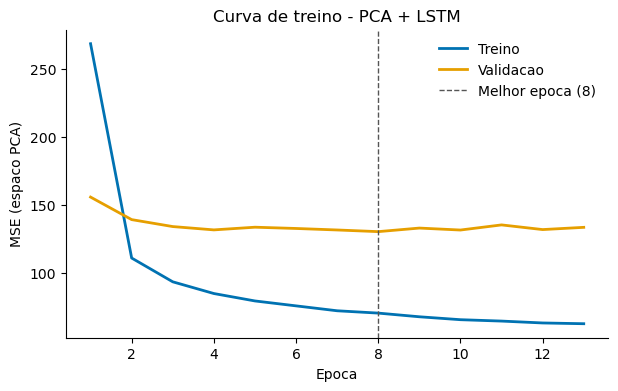

In [2]:
history = pd.read_csv(f"{RUN_DIR}/history.csv")
with open(f"{RUN_DIR}/metrics.json") as f:
    metrics = json.load(f)

best_epoch = metrics["best_epoch"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["epoch"], history["train_mse_pca"], color=COLORS["modelo"], lw=2, label="Treino")
ax.plot(history["epoch"], history["val_mse_pca"], color=COLORS["climatologia"], lw=2, label="Validacao")
ax.axvline(best_epoch, color="#555555", lw=1, ls="--", label=f"Melhor epoca ({best_epoch})")
ax.set_xlabel("Epoca")
ax.set_ylabel("MSE (espaco PCA)")
ax.set_title("Curva de treino - PCA + LSTM")
ax.legend(frameon=False)
plt.show()

## 2. Comparacao com os baselines

RMSE e MAE calculados na grade real (mm/dia), no conjunto de validacao interna (2019-2022).

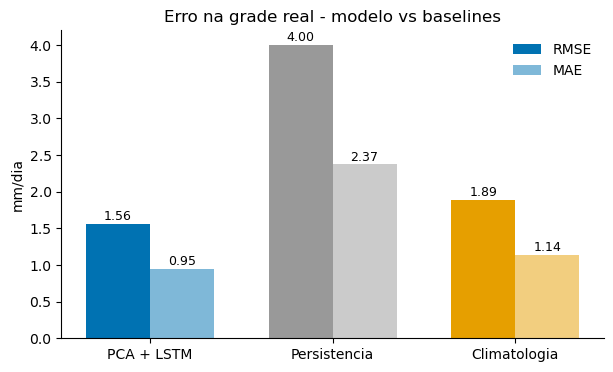

In [3]:
nomes = ["modelo", "persistencia", "climatologia"]
rmse_vals = [metrics[n]["rmse"] for n in nomes]
mae_vals = [metrics[n]["mae"] for n in nomes]

x = np.arange(len(nomes))
largura = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - largura / 2, rmse_vals, largura, label="RMSE", color=[COLORS[n] for n in nomes])
ax.bar(x + largura / 2, mae_vals, largura, label="MAE", color=[COLORS[n] for n in nomes], alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels([LABELS[n] for n in nomes])
ax.set_ylabel("mm/dia")
ax.set_title("Erro na grade real - modelo vs baselines")
ax.legend(frameon=False)

for i, (r, m) in enumerate(zip(rmse_vals, mae_vals)):
    ax.text(i - largura / 2, r + 0.05, f"{r:.2f}", ha="center", fontsize=9)
    ax.text(i + largura / 2, m + 0.05, f"{m:.2f}", ha="center", fontsize=9)

plt.show()

## 3. Erro por horizonte de previsao (lag)

Como o RMSE muda conforme o mes-alvo fica mais distante da origem (dez/2022 no teste real; aqui, da origem de cada exemplo de validacao). Esperado: erro cresce com o lag para o modelo e a persistencia; a climatologia tende a ficar estavel (nao depende da origem).

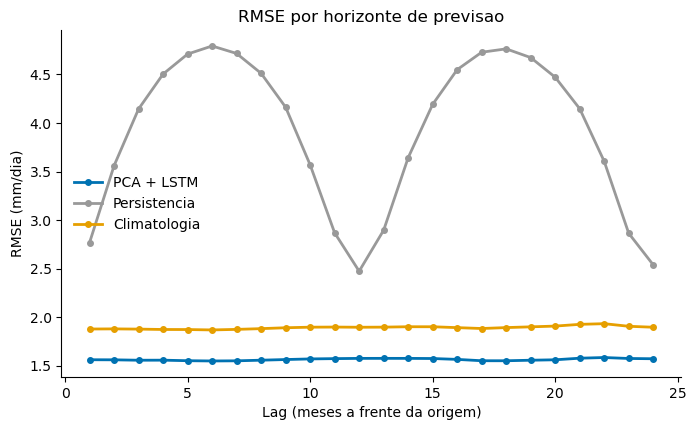

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for nome in nomes:
    por_lag = metrics[nome].get("por_lag")
    if not por_lag:
        continue
    lags_ord = sorted(por_lag.keys(), key=int)
    rmse_lag = [por_lag[l]["rmse"] for l in lags_ord]
    ax.plot([int(l) for l in lags_ord], rmse_lag, marker="o", ms=4, lw=2, color=COLORS[nome], label=LABELS[nome])

ax.set_xlabel("Lag (meses a frente da origem)")
ax.set_ylabel("RMSE (mm/dia)")
ax.set_title("RMSE por horizonte de previsao")
ax.legend(frameon=False)
plt.show()

## 4. Mapas espaciais de exemplo

Para alguns lags representativos (1, 3, 6, 12, 18, 24 meses, quando disponiveis na
validacao), compara o campo real de precipitacao com a previsao do modelo, os dois
baselines, e o erro (previsto - real).

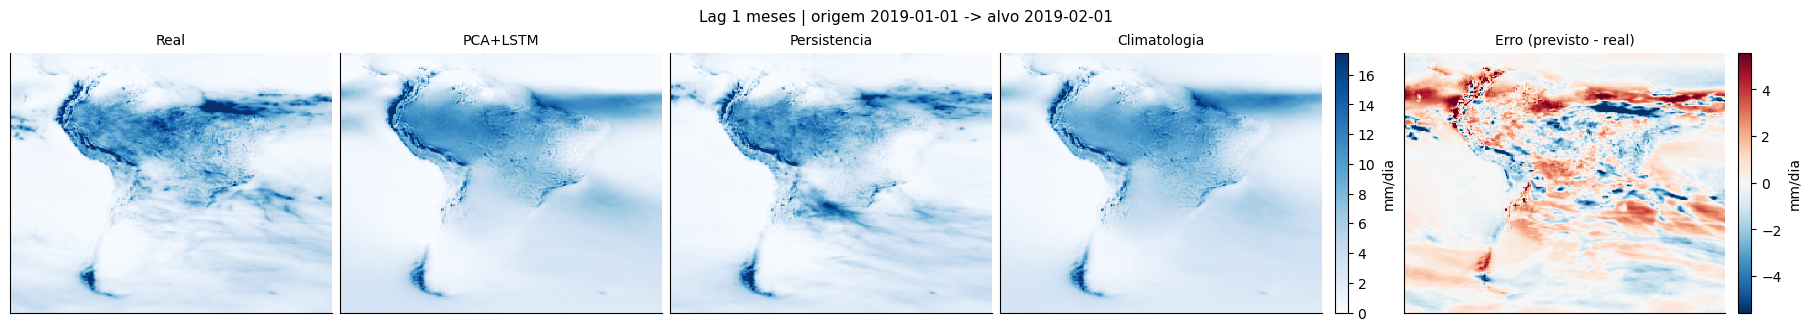

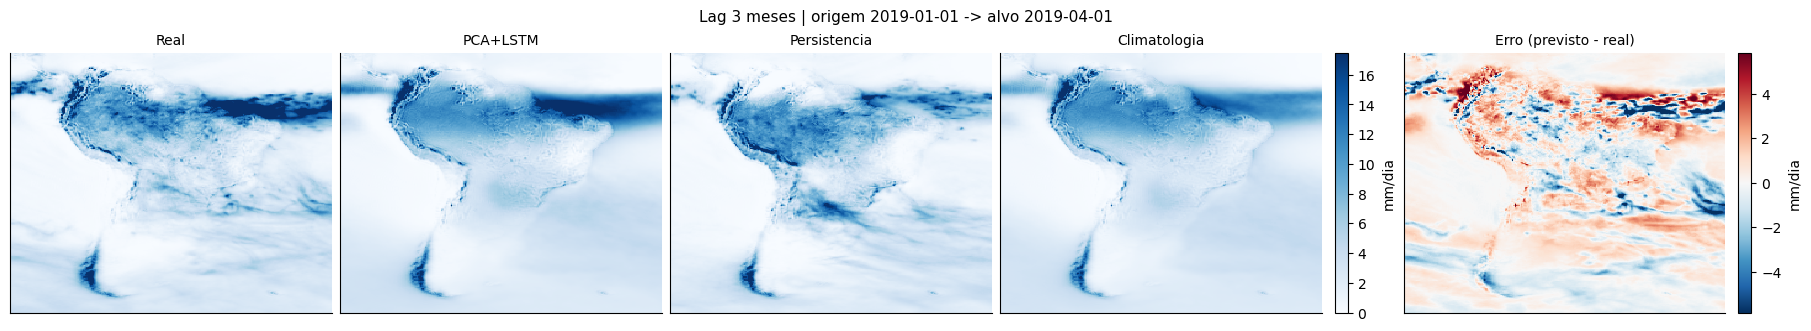

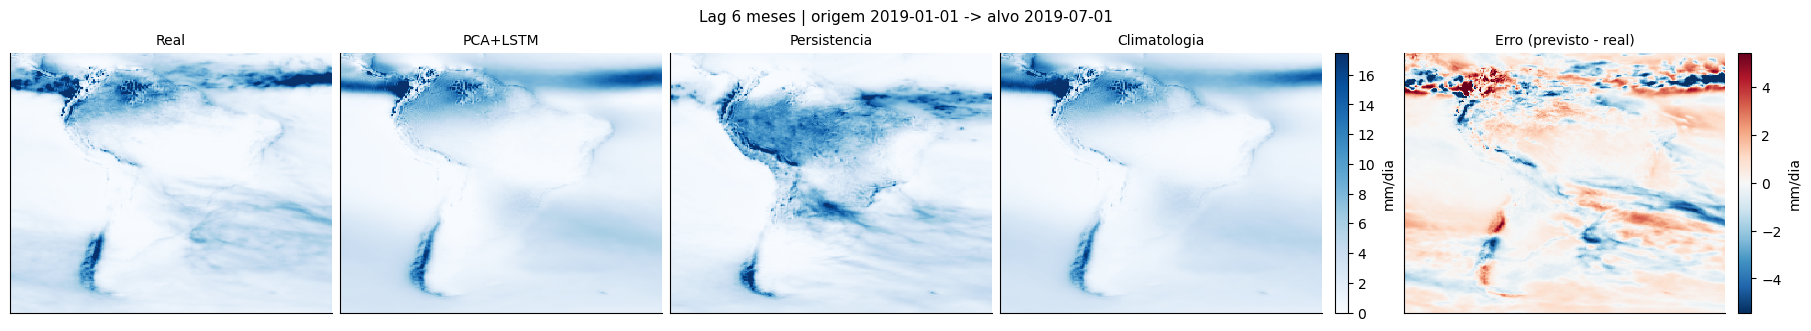

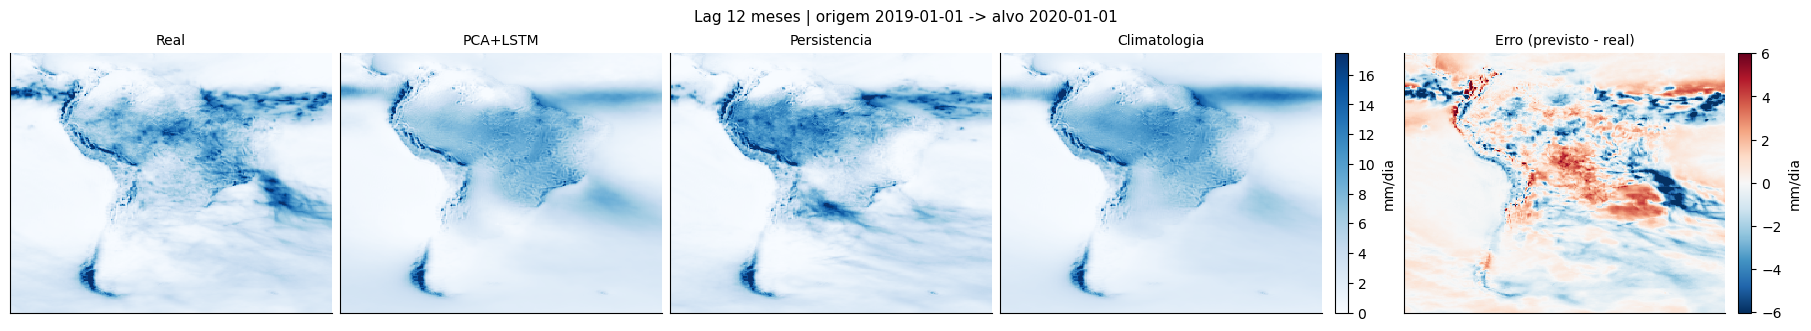

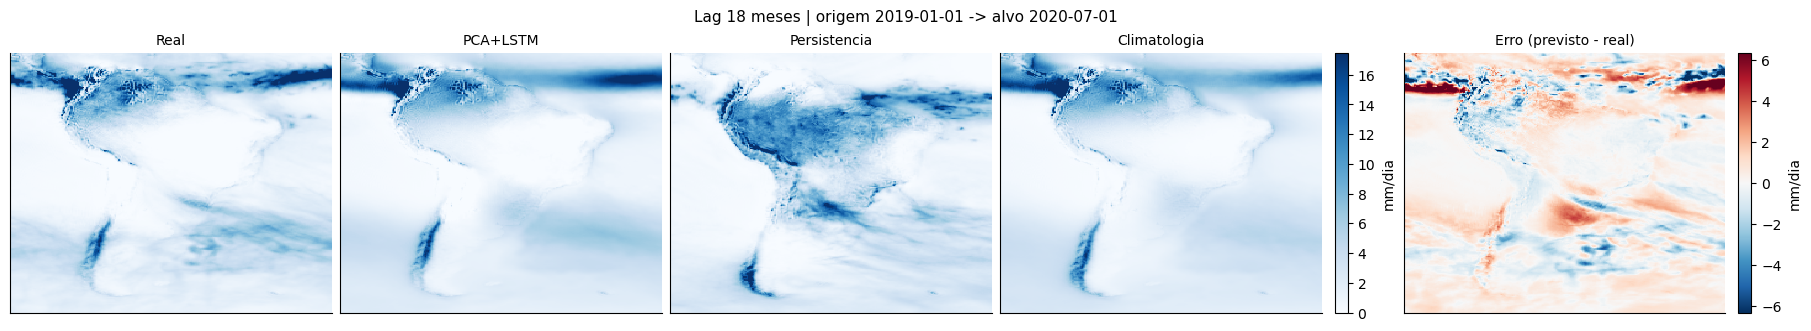

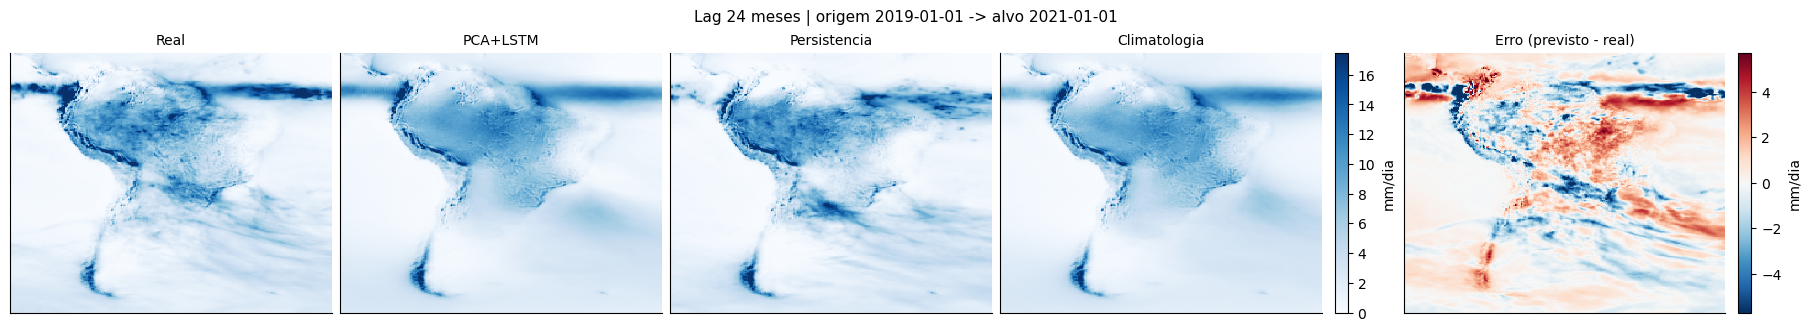

In [5]:
dados = np.load(f"{RUN_DIR}/sample_grids.npz")
lat, lon = dados["lat"], dados["lon"]
lags_amostra = dados["lags"]

vmax_precip = np.nanpercentile(dados["true"], 99)

for i, lag in enumerate(lags_amostra):
    fig, axes = plt.subplots(1, 5, figsize=(18, 3.2), constrained_layout=True)
    campos = [
        ("Real", dados["true"][i], "Blues", 0, vmax_precip),
        ("PCA+LSTM", dados["pred"][i], "Blues", 0, vmax_precip),
        ("Persistencia", dados["persist"][i], "Blues", 0, vmax_precip),
        ("Climatologia", dados["clim"][i], "Blues", 0, vmax_precip),
    ]
    for ax, (titulo, campo, cmap, vmin, vmax) in zip(axes[:4], campos):
        im = ax.pcolormesh(lon, lat, campo, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
        ax.set_title(titulo, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04, label="mm/dia")

    erro = dados["pred"][i] - dados["true"][i]
    lim = np.nanpercentile(np.abs(erro), 99)
    im_err = axes[4].pcolormesh(lon, lat, erro, cmap="RdBu_r", vmin=-lim, vmax=lim, shading="auto")
    axes[4].set_title("Erro (previsto - real)", fontsize=10)
    axes[4].set_xticks([])
    axes[4].set_yticks([])
    fig.colorbar(im_err, ax=axes[4], fraction=0.046, pad=0.04, label="mm/dia")

    fig.suptitle(
        f"Lag {lag} meses | origem {dados['origin_date'][i]} -> alvo {dados['target_date'][i]}",
        fontsize=11,
    )
    plt.show()

## Notas

- Metricas e mapas sao do conjunto de **validacao interna** (origens 2019-2022,
  nunca usadas para treinar o modelo nesta fase) - ver `PLANO_TRABALHO.md`.
- O modelo final enviado para o Kaggle (`submissions/submission_pca_lstm.csv`) foi
  retreinado com todo o historico 1940-2022, usando o numero de epocas escolhido
  aqui - o desempenho real no teste (2023-2024) pode diferir um pouco deste
  relatorio, ja que o teste e extrapolacao alem do periodo rotulado.
- Para regenerar estes artefatos com outros hiperparametros, edite as constantes
  no topo de `src/train_pca_lstm.py` e rode `python3 -m src.train_pca_lstm`
  novamente.